# ODD + OOD Detection for Safe Autonomy
**Camera-based safety gate for autonomous driving**

- **Input**: Front camera frame
- **Output**: "Trust / Abstain" gate decision
- **ODD**: Daytime + Clear weather + Urban/Highway
- **OOD buckets**: Night, Rain, Fog/Snow

**Members**: Tharun Reddy Challabotla, HariChandana Srikurmum, Srija

## 1. Setup & Installation

In [1]:
# Install dependencies
!pip install -q torch torchvision scikit-learn matplotlib seaborn tqdm
!pip install -q kagglehub

In [2]:
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 2. Dataset Download (BDD100K Weather Classification via kagglehub)

Uses `kagglehub` — no `kaggle.json` file upload needed.  
On first run it will ask you to authenticate via browser (one-time). The dataset is cached in `~/.cache/kagglehub` and reused on subsequent runs.

In [3]:
import kagglehub

# Download latest version — authenticates via browser on first run
# Credentials are cached in ~/.cache/kagglehub after the first login
kaggle_path = kagglehub.dataset_download('marquis03/bdd100k-weather-classification')
print('Path to dataset files:', kaggle_path)

from pathlib import Path
BDD_RAW = Path(kaggle_path)

# kagglehub sometimes nests files under a version subfolder;
# find the directory that actually contains train/ and val/ folders
def find_dataset_root(base: Path) -> Path:
    if (base / 'train').exists() or (base / 'val').exists():
        return base
    for child in sorted(base.rglob('train')):
        if child.is_dir():
            return child.parent
    return base
BDD_RAW = find_dataset_root(BDD_RAW)
print(f'Dataset root: {BDD_RAW}')

# Show splits and weather folders
for split in ['train', 'val']:
    split_dir = BDD_RAW / split
    if split_dir.exists():
        folders = [f.name for f in sorted(split_dir.iterdir()) if f.is_dir()]
        print(f'  {split}: {folders}')

100%|██████████| 5.27G/5.27G [05:33<00:00, 17.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/marquis03/bdd100k-weather-classification/versions/1
Dataset root: /root/.cache/kagglehub/datasets/marquis03/bdd100k-weather-classification/versions/1
  train: ['clear', 'foggy', 'overcast', 'partly cloudy', 'rainy', 'snowy', 'unknown']
  val: ['clear', 'foggy', 'overcast', 'partly cloudy', 'rainy', 'snowy', 'unknown']


In [4]:
# Verify dataset structure
DATA_ROOT = BDD_RAW  # alias used throughout the notebook

total_imgs = sum(1 for p in BDD_RAW.rglob('*') if p.suffix.lower() in {'.jpg','.jpeg','.png'})
print(f'Total images found: {total_imgs:,}')

Total images found: 99,863


In [6]:
# --- CELL 1: DATASET MAPPING & PREPROCESSING ---

# Define the binary mapping based on your previous ID vs OOD definitions
# 0 = In-Distribution (Safe/Clear)
# 1 = Out-of-Distribution (Adverse Weather)
WEATHER_MAPPING = {
    'clear': 0,
    'partly cloudy': 0,
    'overcast': 0,
    'rainy': 1,
    'snowy': 1,
    'foggy': 1
}

class BDDWeatherBinaryDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = Path(root_dir) / split
        self.transform = transform
        self.samples = []

        # Iterate through weather folders
        for weather_folder in self.root_dir.iterdir():
            if weather_folder.is_dir() and weather_folder.name.lower() in WEATHER_MAPPING:
                label = WEATHER_MAPPING[weather_folder.name.lower()]
                for img_path in weather_folder.glob('*.jpg'):
                    self.samples.append((str(img_path), label))

        print(f"Loaded {split} split: {len(self.samples)} images.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

# Standard ImageNet Transforms for ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = BDDWeatherBinaryDataset(DATA_ROOT, split='train', transform=transform)
val_dataset = BDDWeatherBinaryDataset(DATA_ROOT, split='val', transform=transform)

# Standard Loaders for Feature Extraction (batch size can be high since no gradients are computed)
extract_train_loader = DataLoader(train_dataset, batch_size=128, shuffle=False, num_workers=2)
extract_val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2)

Loaded train split: 61744 images.
Loaded val split: 8843 images.


In [7]:
# --- CELL 2: EXTRACT AND CACHE BACKBONE FEATURES ---

# Load Pretrained ResNet-50 and strip the final classification head
backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
backbone.fc = nn.Identity() # Replaces the final layer with a pass-through
backbone = backbone.to(DEVICE)
backbone.eval() # Freeze it!

def extract_and_save_features(loader, save_prefix):
    features_list = []
    labels_list = []

    print(f"Extracting features for {save_prefix}...")
    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Processing {save_prefix}"):
            images = images.to(DEVICE)
            # ResNet output shape: [Batch, 2048]
            feats = backbone(images)

            features_list.append(feats.cpu())
            labels_list.append(labels.cpu())

    # Concatenate all batches
    all_features = torch.cat(features_list, dim=0)
    all_labels = torch.cat(labels_list, dim=0)

    # Save to disk as PyTorch tensors
    torch.save(all_features, f"{save_prefix}_features.pt")
    torch.save(all_labels, f"{save_prefix}_labels.pt")
    print(f"Saved {save_prefix}: Features {all_features.shape}, Labels {all_labels.shape}")

# Run extraction (only needs to be done once!)
extract_and_save_features(extract_train_loader, "train")
extract_and_save_features(extract_val_loader, "val")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]


Extracting features for train...


Processing train:   0%|          | 0/483 [00:00<?, ?it/s]

Saved train: Features torch.Size([61744, 2048]), Labels torch.Size([61744])
Extracting features for val...


Processing val:   0%|          | 0/70 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7df81b3487c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7df81b3487c0>self._shutdown_workers()

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        if w.is_alive():self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
       if w.is_alive(): 
       ^  ^ ^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^
    assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/lib/python3

Saved val: Features torch.Size([8843, 2048]), Labels torch.Size([8843])


In [8]:
# --- CELL 3: LOAD CACHED FEATURES ---
from torch.utils.data import TensorDataset

# Load cached tensors
train_features = torch.load("train_features.pt")
train_labels = torch.load("train_labels.pt")

val_features = torch.load("val_features.pt")
val_labels = torch.load("val_labels.pt")

# Create lightning-fast TensorDatasets
vector_train_dataset = TensorDataset(train_features, train_labels)
vector_val_dataset = TensorDataset(val_features, val_labels)

# We can use smaller batch sizes now for actual training
train_loader = DataLoader(vector_train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(vector_val_dataset, batch_size=64, shuffle=False)

In [9]:
# --- CELL 4: DEEP ENSEMBLE ARCHITECTURE ---

class DeepHeadEnsemble(nn.Module):
    def __init__(self, input_dim=2048, num_classes=2, num_models=5):
        super(DeepHeadEnsemble, self).__init__()
        self.num_models = num_models

        # Create a list of independent MLPs
        # input_dim is 2048 because that's the output size of ResNet-50
        self.models = nn.ModuleList([
            nn.Sequential(
                nn.Linear(input_dim, 512),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(512, 128),
                nn.ReLU(),
                nn.Linear(128, num_classes)
            ) for _ in range(num_models)
        ])

    def forward(self, x):
        # x shape: [batch_size, 2048]
        # returns stacked logits: shape [batch_size, num_models, num_classes]
        logits = torch.stack([model(x) for model in self.models], dim=1)
        return logits

# Initialize the model and optimizer
ensemble_model = DeepHeadEnsemble(input_dim=2048, num_classes=2, num_models=5).to(DEVICE)
optimizer = torch.optim.Adam(ensemble_model.parameters(), lr=1e-4, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

In [10]:
# --- CELL 5: TRAINING LOOP ---

EPOCHS = 15

print("Starting Ensemble Training...")
for epoch in range(EPOCHS):
    ensemble_model.train()
    total_loss = 0.0

    for features, labels in train_loader:
        features, labels = features.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        # Forward pass: shape [batch, 5, 2]
        logits_stack = ensemble_model(features)

        # Calculate loss for each of the 5 models and sum them
        loss = 0
        for i in range(ensemble_model.num_models):
            loss += criterion(logits_stack[:, i, :], labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Avg Ensemble Loss: {avg_loss:.4f}")

Starting Ensemble Training...
Epoch 1/15 | Avg Ensemble Loss: 1.4231
Epoch 2/15 | Avg Ensemble Loss: 1.1784
Epoch 3/15 | Avg Ensemble Loss: 1.1253
Epoch 4/15 | Avg Ensemble Loss: 1.0673
Epoch 5/15 | Avg Ensemble Loss: 1.0170
Epoch 6/15 | Avg Ensemble Loss: 0.9668
Epoch 7/15 | Avg Ensemble Loss: 0.9095
Epoch 8/15 | Avg Ensemble Loss: 0.8583
Epoch 9/15 | Avg Ensemble Loss: 0.7932
Epoch 10/15 | Avg Ensemble Loss: 0.7280
Epoch 11/15 | Avg Ensemble Loss: 0.6591
Epoch 12/15 | Avg Ensemble Loss: 0.5910
Epoch 13/15 | Avg Ensemble Loss: 0.5266
Epoch 14/15 | Avg Ensemble Loss: 0.4680
Epoch 15/15 | Avg Ensemble Loss: 0.4060


Evaluating on Validation Data...
Ensemble Accuracy: 91.38%


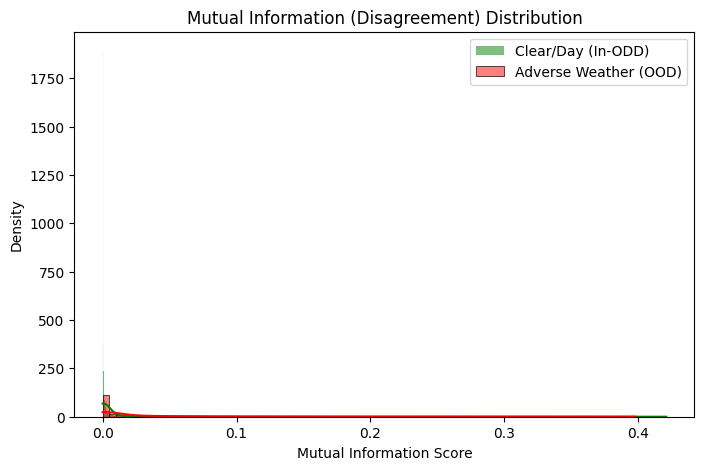

In [11]:
# --- CELL 6: EVALUATION & UNCERTAINTY CALCULATION ---

def evaluate_ensemble(model, loader):
    model.eval()

    all_entropy = []
    all_mi = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(DEVICE)

            # 1. Get logits from all 5 models: [batch, 5, 2]
            logits_stack = model(features)

            # 2. Convert to probabilities: [batch, 5, 2]
            probs_stack = F.softmax(logits_stack, dim=-1)

            # 3. Calculate Mean Probability (The consensus): [batch, 2]
            mean_probs = torch.mean(probs_stack, dim=1)

            # 4. Predict based on the consensus
            preds = torch.argmax(mean_probs, dim=-1)

            # --- UNCERTAINTY METRICS ---

            # Predictive Entropy (Total Uncertainty)
            # H = - sum( p * log(p) )
            entropy = -torch.sum(mean_probs * torch.log(mean_probs + 1e-8), dim=-1)

            # Mutual Information (Model Disagreement/Epistemic Uncertainty)
            # MI = Total Entropy - Expected Data Entropy
            indiv_entropies = -torch.sum(probs_stack * torch.log(probs_stack + 1e-8), dim=-1)
            mean_indiv_entropy = torch.mean(indiv_entropies, dim=1)
            mi = entropy - mean_indiv_entropy

            # Store everything
            all_entropy.extend(entropy.cpu().numpy())
            all_mi.extend(mi.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return (np.array(all_preds), np.array(all_labels),
            np.array(all_entropy), np.array(all_mi))

# Run Evaluation on Validation Set
print("Evaluating on Validation Data...")
val_preds, val_labels_arr, val_entropy, val_mi = evaluate_ensemble(ensemble_model, val_loader)

# Calculate standard accuracy
acc = accuracy_score(val_labels_arr, val_preds)
print(f"Ensemble Accuracy: {acc * 100:.2f}%")

# Plot the Mutual Information Distribution (This is your new Safety Gate Score!)
plt.figure(figsize=(8,5))
sns.histplot(data=val_mi[val_labels_arr == 0], color="green", label="Clear/Day (In-ODD)", kde=True, stat="density")
sns.histplot(data=val_mi[val_labels_arr == 1], color="red", label="Adverse Weather (OOD)", kde=True, stat="density")
plt.title("Mutual Information (Disagreement) Distribution")
plt.xlabel("Mutual Information Score")
plt.ylabel("Density")
plt.legend()
plt.show()

In [12]:
# --- CELL 7: DEPLOYED RUNTIME SAFETY GATE ---

# Set the threshold based on the intersection from our distribution plot
SAFETY_THRESHOLD = 0.25

def runtime_safety_gate(features, ensemble_model, threshold=SAFETY_THRESHOLD):
    """
    Simulates the real-time decision making of the autonomous vehicle.
    Takes in extracted features of an image (or batch of images).
    """
    ensemble_model.eval()

    with torch.no_grad():
        features = features.to(DEVICE)

        # 1. Get predictions from all 5 models in the ensemble
        logits_stack = ensemble_model(features)       # Shape: [batch, 5, 2]
        probs_stack = F.softmax(logits_stack, dim=-1) # Shape: [batch, 5, 2]

        # 2. Calculate the consensus (Mean Probability)
        mean_probs = torch.mean(probs_stack, dim=1)   # Shape: [batch, 2]
        preds = torch.argmax(mean_probs, dim=-1)      # Shape: [batch]

        # 3. Calculate Uncertainty (Mutual Information)
        entropy = -torch.sum(mean_probs * torch.log(mean_probs + 1e-8), dim=-1)
        indiv_entropies = -torch.sum(probs_stack * torch.log(probs_stack + 1e-8), dim=-1)
        mean_indiv_entropy = torch.mean(indiv_entropies, dim=1)

        mutual_info = entropy - mean_indiv_entropy    # Shape: [batch]

        # 4. The Decision Logic
        decisions = []
        for i in range(len(mutual_info)):
            mi_score = mutual_info[i].item()
            pred_class = preds[i].item()

            # THE GATE: If models disagree (high MI), we abstain!
            if mi_score > threshold:
                decisions.append(("ABSTAIN", mi_score, None))
            else:
                decisions.append(("TRUST", mi_score, pred_class))

        return decisions

# --- SIMULATE REAL-WORLD DEPLOYMENT ---
print(f"Deploying Safety Gate with Threshold: τ = {SAFETY_THRESHOLD}\n")
print("="*60)

# Let's test it on a random batch of 10 validation images
sample_features, sample_labels = next(iter(val_loader))

# Run the features through the safety gate
gate_results = runtime_safety_gate(sample_features[:10], ensemble_model)

# Print the real-time decisions for analysis
for i, (decision, mi_score, pred_class) in enumerate(gate_results):
    true_label = sample_labels[i].item()
    actual_weather = "Clear Day (In-ODD)" if true_label == 0 else "Adverse Weather (OOD)"

    print(f"Frame {i+1} [Ground Truth: {actual_weather}]:")
    print(f"  -> Mutual Info Score : {mi_score:.4f}")

    if decision == "ABSTAIN":
        print(f"  -> System Action     : 🛑 ABSTAIN (High uncertainty detected. Handing over to human driver.)")
    else:
        pred_weather = "Clear Day" if pred_class == 0 else "Adverse Weather"
        print(f"  -> System Action     : ✅ TRUST (Low uncertainty. Safe to proceed. Predicted: {pred_weather})")
    print("-" * 60)

Deploying Safety Gate with Threshold: τ = 0.25

Frame 1 [Ground Truth: Clear Day (In-ODD)]:
  -> Mutual Info Score : 0.1179
  -> System Action     : ✅ TRUST (Low uncertainty. Safe to proceed. Predicted: Adverse Weather)
------------------------------------------------------------
Frame 2 [Ground Truth: Clear Day (In-ODD)]:
  -> Mutual Info Score : 0.0003
  -> System Action     : ✅ TRUST (Low uncertainty. Safe to proceed. Predicted: Clear Day)
------------------------------------------------------------
Frame 3 [Ground Truth: Clear Day (In-ODD)]:
  -> Mutual Info Score : 0.0000
  -> System Action     : ✅ TRUST (Low uncertainty. Safe to proceed. Predicted: Clear Day)
------------------------------------------------------------
Frame 4 [Ground Truth: Clear Day (In-ODD)]:
  -> Mutual Info Score : 0.0004
  -> System Action     : ✅ TRUST (Low uncertainty. Safe to proceed. Predicted: Clear Day)
------------------------------------------------------------
Frame 5 [Ground Truth: Clear Day (In-O